# **Data Exploration**
The dataset has been cleaned properly and now resides within an easily accessible CSV file. Now is the time to explore the data through summary statistic, **statistical methods**, and **data plotting**.

**Step 1:** Import necessary libraries
- **pandas** for data handling
- **ADD ADDITIONAL LIBRARIES HERE** as well as a short explanation for their use

In [1]:
import pandas as pd

from scipy.stats import f_oneway ## For ANOVA test
from scipy.stats import tukey_hsd ## Post-hoc test for ANOVA

import matplotlib.pyplot as plt
import seaborn as sns

**Step 2.1:** Perform data exploration using a unique statistical method (see rubric).

Intro:
One way that we are going to explore the dataset is by looking at how the different variables correlate to each other. Measuring the relationship between the variables can show us which variables are linked. The correlation number ranges from -1 (perfect negative correlation) to +1 (perfect positive correlation).

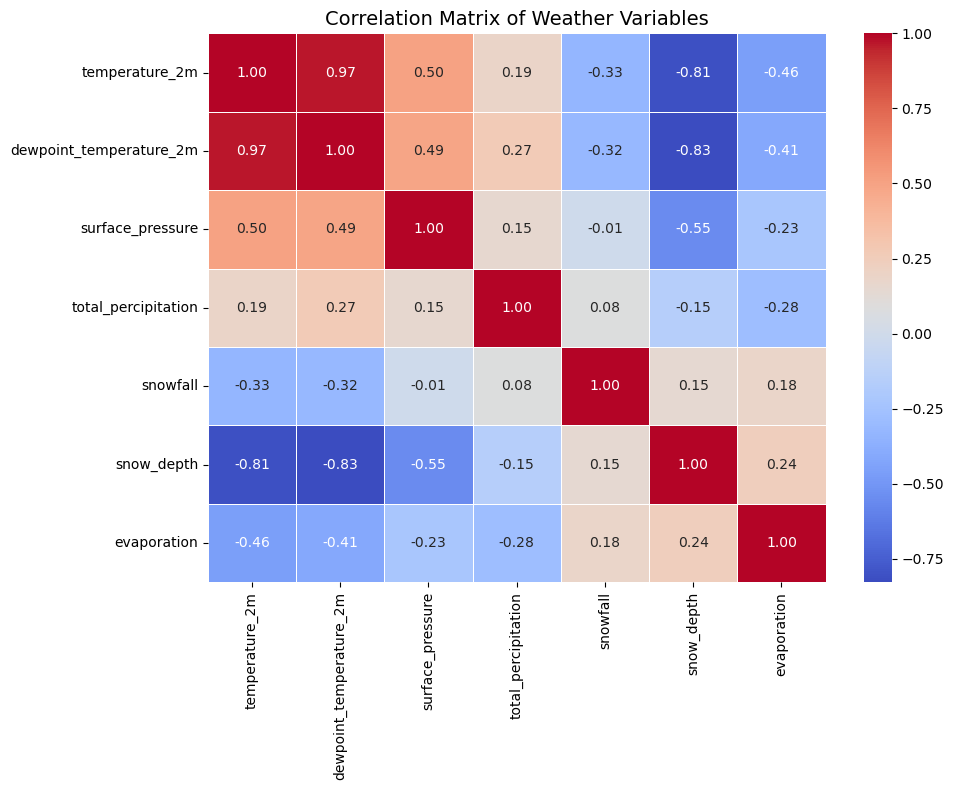

In [3]:
df = pd.read_csv("weather.csv")

corr_cols = [
    "temperature_2m",
    "dewpoint_temperature_2m",
    "surface_pressure",
    "total_percipitation",
    "snowfall",
    "snow_depth",
    "evaporation"
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Weather Variables", fontsize=14)
plt.tight_layout()
plt.show()

Conclusion:
It is clear that temperature and dewpoint are strongly correlated, .97, which makes sense since warm air holds more moisture, so they rise and fall together. Snow depth and temperature is strongly negatively correlated, -.81, pretty obvious that cold air leads to more snow. Snow depth and dewpoint are also strongly negative, -.83, because drier cold air means more snow sticks. Surface pressure and temperature are moderately positive, .5, since warmer air can create higher pressure systems. And precipitation is weakly correlated with pretty much everything, which is because rain depends on more complex factors, not just temperature.

**Step 3.1:** Perform data exploration using a unique statistical method (see rubric).

**Step 4.1:** Perform data exploration using hypothesis testing (see rubric).

In [27]:
#Null Hypothesis: Average temperature across continents are the same.
#Alternative Hypothesis: Average temperature across continents are not the same.

hypo_df = pd.read_csv('weather.csv')

hypo_df['latitude_bands'] = pd.cut(hypo_df['latitude'], bins=[-90, -30, 30, 90], labels=['Southern', 'Mid', 'Northern'], include_lowest=True)

hypo_df['total_precipitation_mm'] = hypo_df['total_percipitation'] * 1000
rainy_days_df = hypo_df[hypo_df['total_precipitation_mm'] > 0]
# rainy_days_df.groupby('latitude_bands')['total_precipitation_mm'].describe()

south = rainy_days_df[rainy_days_df['latitude_bands'] == 'Southern']['total_precipitation_mm']
mid = rainy_days_df[rainy_days_df['latitude_bands'] == 'Mid']['total_precipitation_mm']
north = rainy_days_df[rainy_days_df['latitude_bands'] == 'Northern']['total_precipitation_mm']


f_statistic, p_value = f_oneway(south, mid, north)

print(f"P-value: {p_value}")

P-value: 7.142553035676119e-11


In [28]:
result = tukey_hsd(south, mid, north)
print(result)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.062     0.000    -0.083    -0.040
 (0 - 2)     -0.044     0.000    -0.066    -0.022
 (1 - 0)      0.062     0.000     0.040     0.083
 (1 - 2)      0.018     0.076    -0.001     0.037
 (2 - 0)      0.044     0.000     0.022     0.066
 (2 - 1)     -0.018     0.076    -0.037     0.001



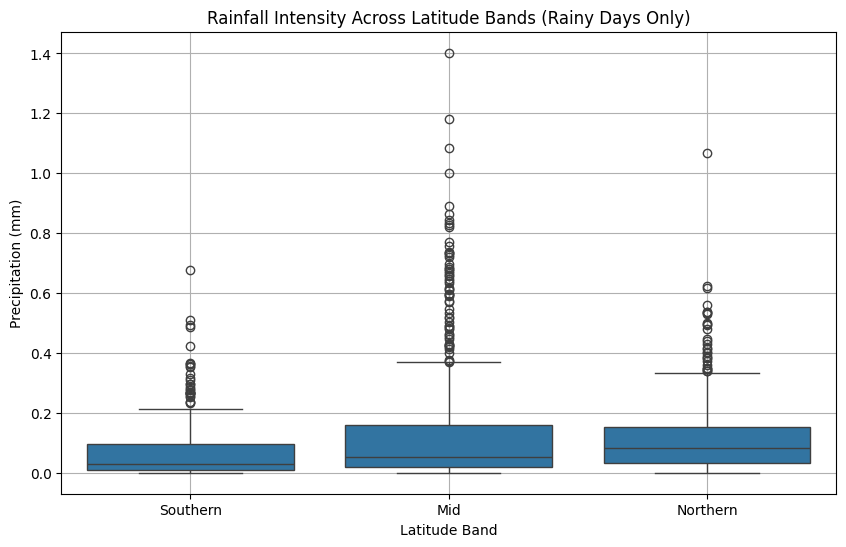

In [37]:
plt.figure(figsize=(10,6))
sns.boxplot(data=rainy_days_df, x='latitude_bands', y='total_precipitation_mm')

plt.title('Rainfall Intensity Across Latitude Bands (Rainy Days Only)')
plt.xlabel('Latitude Band')
plt.ylabel('Precipitation (mm)')
plt.grid(True)

plt.show()